# 👨🏻‍🏫 Statistics & Probabilities

* Date - Monday, April 28, 2025
* Lecturer - Davy WAI




## 📚 Libraries

In [ ]:
# DATA MANIPULATION
import numpy as np
import pandas as pd

# DATA VIZ
import matplotlib.pyplot as plt
import seaborn as sns


# MATH
import math
import scipy
import scipy.stats as stats

## ♦️ Statistics

### 🔢 Collecting data

**Experiment**: ask students in a University class to give their **weight** (in pounds).

Male (57)

```
140 145 160 190 155 165 150 190 195 138 160 155 153 145 170 175 175 170 180
135 170 157 130 185 190 155 170 155 215 150 145 155 155 150 155 150 180 160
135 160 130 155 150 148 155 150 140 180 190 145 150 164 140 142 136 123 155
```

Female (35)

```
140 120 130 138 121 116 125 145 150 112 125 130 120 130 131 120 118 125 135
125 118 122 115 102 115 150 110 116 108  95 125 133 110 150 108
```

We can convert this raw data into a **DataFrame**:

In [ ]:
male_df = pd.DataFrame([140, 145, 160, 190, 155, 165, 150, 190, 195, 138, 160, 155, 153, 145, 170, 175, 175, 170, 180, 135, 170, 157, 130, 185, 190, 155, 170, 155, 215, 150, 145, 155, 155, 150, 155, 150, 180, 160, 135, 160, 130, 155, 150, 148, 155, 150, 140, 180, 190, 145, 150, 164, 140, 142, 136, 123, 155],
    columns=['weight'])
male_df['sex'] = 'male'
female_df = pd.DataFrame([140, 120, 130, 138, 121, 116, 125, 145, 150, 112, 125, 130, 120, 130, 131, 120, 118, 125, 135, 125, 118, 122, 115, 102, 115, 150, 110, 116, 108, 95, 125, 133, 110, 150, 108],
    columns=['weight'])
female_df['sex'] = 'female'

weights_df = pd.concat([male_df, female_df], ignore_index=True)


In [ ]:
weights_df.shape

(92, 2)

In [ ]:
weights_df.columns

Index(['weight', 'sex'], dtype='object')

In [ ]:
weights_df["sex"].value_counts()

male      57
female    35
Name: sex, dtype: int64

In [ ]:
weights_df["sex"].value_counts(normalize=True)

male      0.619565
female    0.380435
Name: sex, dtype: float64

### 🕵 Exploration

We can now **plot** the data. For every number between `95` and `215`, plot a bar chart counting the number of people for a given weight.

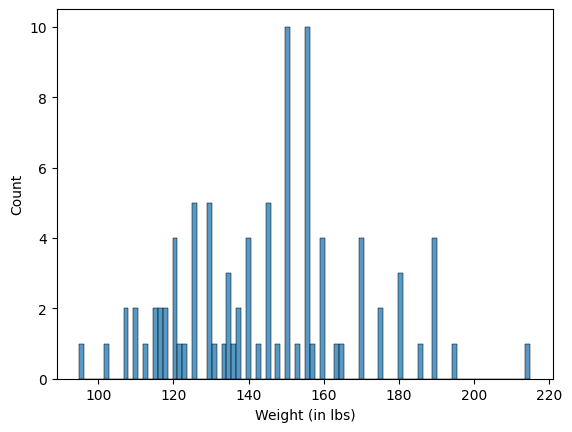

In [ ]:
ax = sns.histplot(weights_df["weight"], bins=len(weights_df))
ax.set_xlabel("Weight (in lbs)")
plt.show()

### 📊 Histogram Bins

Instead of drawing one bar per integer in $[ 95, 215 ]$, we can create **12** bins and count weights falling into these intervals.

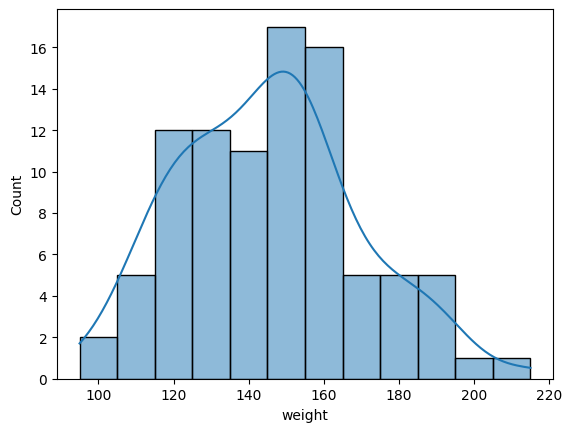

In [ ]:
sns.histplot(weights_df["weight"], bins=12, kde=True)
plt.show()

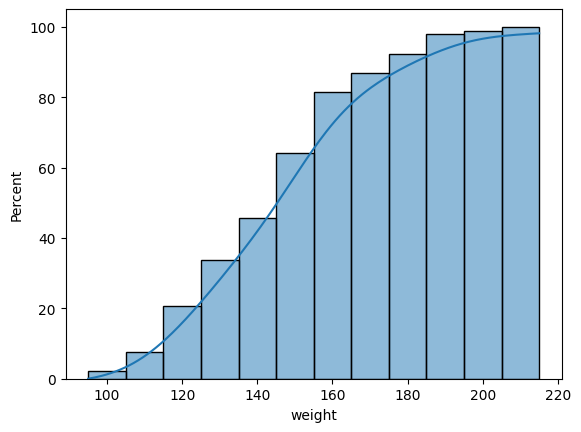

In [ ]:
sns.histplot(weights_df["weight"], bins=12, kde=True, cumulative=True, stat="percent")
plt.show()

### ℹ️ Summary statistics

In [ ]:
weights_df['weight'].describe()

count     92.000000
mean     145.152174
std       23.739398
min       95.000000
25%      125.000000
50%      145.000000
75%      155.500000
max      215.000000
Name: weight, dtype: float64

In [ ]:
Q1 = weights_df['weight'].describe()['25%']
Q1

125.0

In [ ]:
Q3 = weights_df['weight'].describe()['25%']
Q3

125.0

In [ ]:
IQR = Q3 - Q1
IQR

0.0

In [ ]:
lower_bound = Q1 - 1.5 * IQR
lower_bound

125.0

In [ ]:
upper_bound = Q3 + 1.5 * IQR
upper_bound

125.0

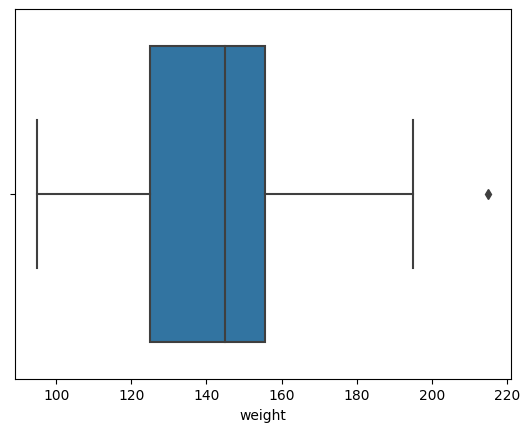

In [ ]:
sns.boxplot(x=weights_df['weight'])
plt.show()

## 🎲 Probability Theory

### 🐣 [Bernoulli process](https://en.wikipedia.org/wiki/Bernoulli_process)


A repeated sequence of binary random variables (e.g coin flipping), with a probability $p$ of getting $1$ (e.g. _Heads_)

In [ ]:
np.random.binomial(n=1, p=0.3, size=10)
# size = 10 trials or "coin flips" with a rigged coin (0.3 of heads)
# n=1 repetition of "coin flips"

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [ ]:
n = 5
np.random.binomial(n=n, p=0.3, size=10) / n # Divide by n to get the mean

array([0.2, 0.4, 0.4, 0. , 0. , 0.4, 0.2, 0.4, 0. , 0.4])

/Users/davywai/.pyenv/versions/3.8.12/envs/lewagon_data_staff/lib/python3.8/site-packages/seaborn/distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:>

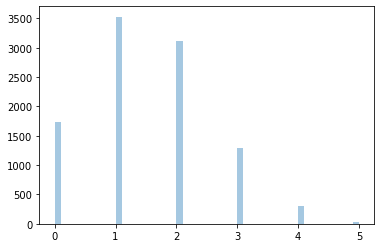

In [ ]:
n = 5
sns.distplot(np.random.binomial(n=n, p=0.3, size=10000), kde=False)

### 🐥 Binomial Distribution

This is called a **Binomial Distribution** $B(n, p)$. Its PMF (Probability Mass Function) is:

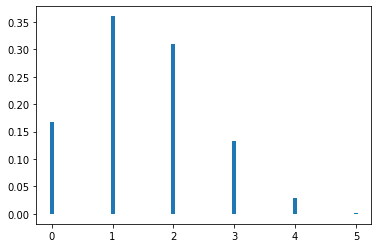

In [ ]:
n = 5
p = 0.3

x = np.arange(n + 1)
pmf = stats.binom.pmf(x, n, p)
plt.vlines(x, 0, pmf, linewidth=4)

As $n$ increases, the mean of Bernouilli processes is **approximated** by a [normal distribution](https://en.wikipedia.org/wiki/Normal_distribution)

<AxesSubplot:ylabel='Density'>

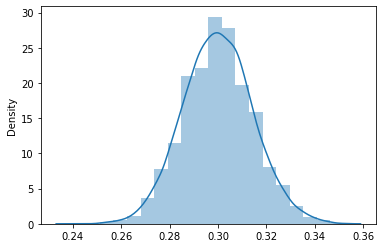

In [ ]:
n = 1000
sns.distplot(np.random.binomial(n=n, p=0.3, size=10000) / n, bins=20)

### 🚀 Normal Distribution


PDF (Probability Density Function) is:

$${\mathcal N(\mu, \sigma) ={\frac {1}{\sqrt {2\pi \sigma ^{2}}}}e^{-{\frac {(x-\mu )^{2}}{2\sigma ^{2}}}}}$$

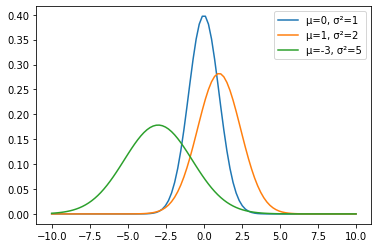

In [ ]:
def plot_normal_distribution(mu, variance):
    sigma = math.sqrt(variance)
    x = np.linspace(-10, 10, 100)
    plt.plot(x, stats.norm.pdf(x, mu, sigma), label=f"μ={mu}, σ²={variance}")

plot_normal_distribution(0, 1)
plot_normal_distribution(1, 2)
plot_normal_distribution(-3, 5)
plt.legend()
plt.show()